In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm.auto import tqdm
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
import torch.nn.functional as F
import gc

from multiprocessing import Pool
import random
import seaborn as sns
from cosine_annealing_warmup import CosineAnnealingWarmupRestarts as CAWR

import torch
torch.set_default_dtype(torch.float64)

from util import *

In [2]:
signal_list  = [
    "B0_st",
    "cas_q_hl_32",
    "cas_c_hh_12",
    "lambcs_bc_32"]

## B0_st

In [3]:
signal = signal_list[0]
DATA_PATH = "../../../CorrelatorStudy/Bdata/ext2/"
f = open(f"{DATA_PATH}/{signal}", "r")
data = f.readlines()
f.close()

y_raw = np.array(list(map(lambda x: abs(float(x.split("\t")[-1].split("\n")[0])), data)), dtype=float)
x_raw = np.array(list(map(lambda x: float(x.split("\t")[0].split("\n")[0]), data)), dtype=float)


idx = (x_raw>=0)

x = x_raw[idx]
y = y_raw[idx]

device = "cuda:0"
BATCH_SIZE = 512
noise_dim = 64
model = Guess(feature_size=noise_dim,
              mul=4,
              nparam=4)

model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(),lr = 1e-3)


x_tensor = torch.tensor(x,device=device,dtype=torch.float64)
y_tensor = torch.tensor(y,device=device,dtype=torch.float64)

model = train_guess_network(model=model,
                            x_tensor=x_tensor,
                            y_tensor=y_tensor,
                            NEpochs=50_000,
                            optimizer=optimizer,
                            BATCH_SIZE=BATCH_SIZE,
                            noise_dim=noise_dim,
                            device=device,
                            verbose=True)

Training:   0%|          | 0/50000 [00:00<?, ?it/s]

In [23]:
with torch.no_grad():
    noise = torch.randn(6400,noise_dim,device=device)
    e,c = model(noise)
    e = e.to("cpu")

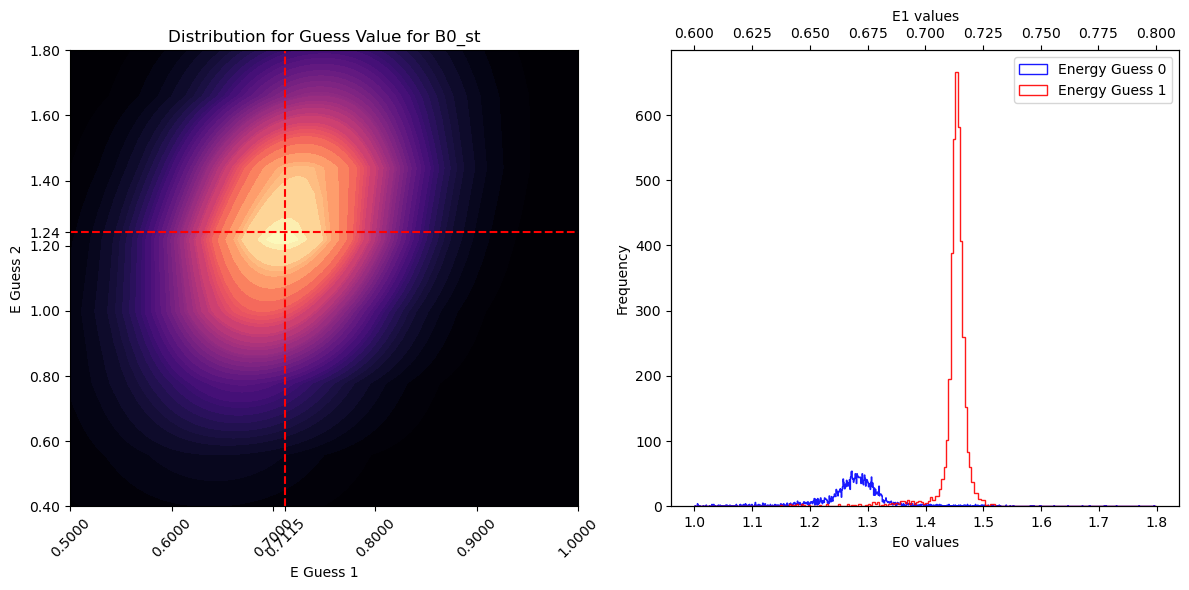

In [32]:
e_np = np.array(e)

m1 = np.median(e_np[:, 0])
m2 = np.median(e_np[:, 1])

bins_e0 = np.arange(0.6, 0.8, 0.001)
bins_e1 = np.arange(1.0, 1.8, 0.001)

fig, (ax_kde, ax_hist) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 6),)


sns.kdeplot(
    x=e_np[:, 0],
    y=e_np[:, 1],
    fill=True,
    cmap="magma",
    thresh=0,
    levels=40,
    ax=ax_kde
)

ax_kde.axhline(y=m2, color="red", linestyle="--")
ax_kde.axvline(x=m1, color="red", linestyle="--")

ax_kde.set_xlabel("E Guess 1")
ax_kde.set_ylabel("E Guess 2")
ax_kde.set_ylim(0.5, 1.8)
ax_kde.set_xlim(0.5, 1)
ax_kde.set_title(f"Distribution for Guess Value for {signal}")


xticks = list(ax_kde.get_xticks()) + [m1]
yticks = list(ax_kde.get_yticks()) + [m2]
ax_kde.set_xticks(xticks)
ax_kde.set_yticks(yticks)

for label in ax_kde.get_xticklabels():
    label.set_rotation(45)


ax1 = ax_hist

ax1.hist(
    e_np[:, 1],
    bins=bins_e1,
    alpha=0.9,
    color="blue",
    histtype="step",
    label="Energy Guess 0"
)
ax1.set_xlabel("E0 values")
ax1.set_ylabel("Frequency")

ax2 = ax1.twiny()
ax2.hist(
    e_np[:, 0],
    bins=bins_e0,
    alpha=0.9,
    color="red",
    histtype="step",
    label="Energy Guess 1"
)
ax2.set_xlabel("E1 values")
ax2.xaxis.set_ticks_position("top")
ax2.xaxis.set_label_position("top")


handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

fig.tight_layout()
plt.savefig("../assets/LMA_NG_0.png")
plt.show()


## cas_q_hl_32

In [33]:
signal = signal_list[1]
DATA_PATH = "../../../CorrelatorStudy/Bdata/ext2/"
f = open(f"{DATA_PATH}/{signal}", "r")
data = f.readlines()
f.close()

y_raw = np.array(list(map(lambda x: abs(float(x.split("\t")[-1].split("\n")[0])), data)), dtype=float)
x_raw = np.array(list(map(lambda x: float(x.split("\t")[0].split("\n")[0]), data)), dtype=float)


idx = (x_raw>=0)

x = x_raw[idx]
y = y_raw[idx]

device = "cuda:0"
BATCH_SIZE = 512
noise_dim = 64
model = Guess(feature_size=noise_dim,
              mul=4,
              nparam=4)

model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(),lr = 1e-3)


x_tensor = torch.tensor(x,device=device,dtype=torch.float64)
y_tensor = torch.tensor(y,device=device,dtype=torch.float64)

model = train_guess_network(model=model,
                            x_tensor=x_tensor,
                            y_tensor=y_tensor,
                            NEpochs=50_000,
                            optimizer=optimizer,
                            BATCH_SIZE=BATCH_SIZE,
                            noise_dim=noise_dim,
                            device=device,
                            verbose=True)

Training:   0%|          | 0/50000 [00:00<?, ?it/s]

In [34]:
with torch.no_grad():
    noise = torch.randn(6400,noise_dim,device=device)
    e,c = model(noise)
    e = e.to("cpu")

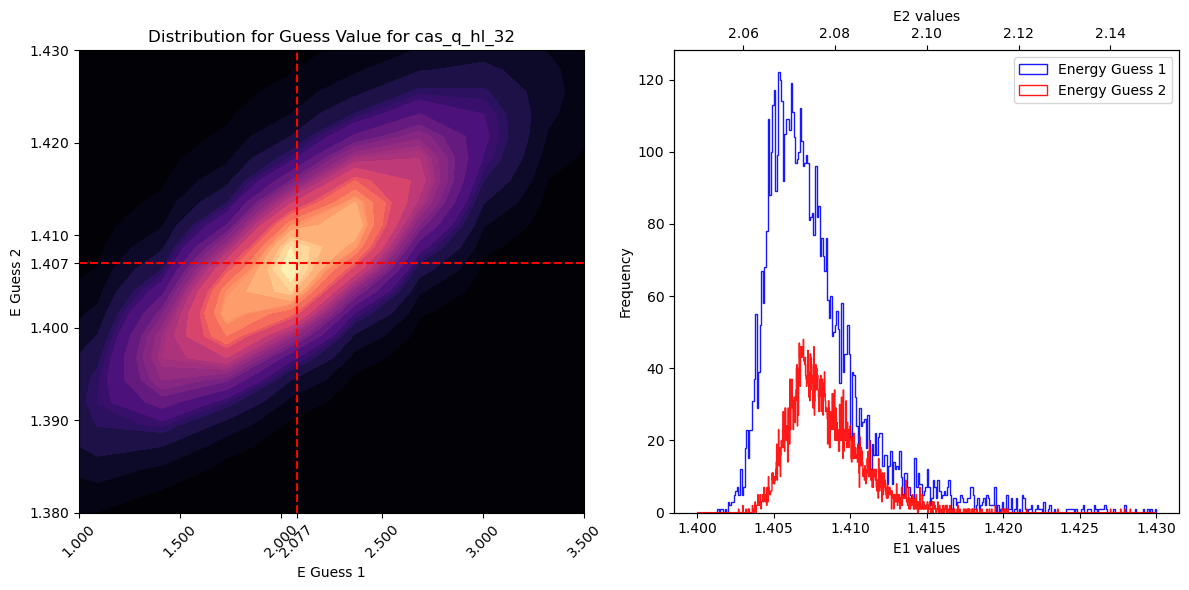

In [59]:
e_np = np.array(e)

m1 = np.median(e_np[:, 0])
m2 = np.median(e_np[:, 1])

bins_e0 = np.arange(2.05, 2.15, 0.0001)
bins_e1 = np.arange(1.4, 1.43, 0.0001)

fig, (ax_kde, ax_hist) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 6),)


sns.kdeplot(
    x=e_np[:, 0],
    y=e_np[:, 1],
    fill=True,
    cmap="magma",
    thresh=0,
    levels=25,
    ax=ax_kde
)

ax_kde.axhline(y=m2, color="red", linestyle="--")
ax_kde.axvline(x=m1, color="red", linestyle="--")

ax_kde.set_xlabel("E Guess 1")
ax_kde.set_ylabel("E Guess 2")
ax_kde.set_ylim(1.38, 1.43)
ax_kde.set_xlim(1, 3.5)
ax_kde.set_title(f"Distribution for Guess Value for {signal}")


xticks = list(ax_kde.get_xticks()) + [m1]
yticks = list(ax_kde.get_yticks()) + [m2]
ax_kde.set_xticks(xticks)
ax_kde.set_yticks(yticks)

for label in ax_kde.get_xticklabels():
    label.set_rotation(45)


ax1 = ax_hist

ax1.hist(
    e_np[:, 1],
    bins=bins_e1,
    alpha=0.9,
    color="blue",
    histtype="step",
    label="Energy Guess 1"
)
ax1.set_xlabel("E1 values")
ax1.set_ylabel("Frequency")

ax2 = ax1.twiny()
ax2.hist(
    e_np[:, 0],
    bins=bins_e0,
    alpha=0.9,
    color="red",
    histtype="step",
    label="Energy Guess 2"
)
ax2.set_xlabel("E2 values")
ax2.xaxis.set_ticks_position("top")
ax2.xaxis.set_label_position("top")


handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

fig.tight_layout()
plt.savefig("../assets/LMA_NG_1.png")
plt.show()


## cas_c_hh_12

In [60]:
signal = signal_list[2]
DATA_PATH = "../../../CorrelatorStudy/Bdata/ext2/"
f = open(f"{DATA_PATH}/{signal}", "r")
data = f.readlines()
f.close()

y_raw = np.array(list(map(lambda x: abs(float(x.split("\t")[-1].split("\n")[0])), data)), dtype=float)
x_raw = np.array(list(map(lambda x: float(x.split("\t")[0].split("\n")[0]), data)), dtype=float)


idx = (x_raw>=0)

x = x_raw[idx]
y = y_raw[idx]

device = "cuda:0"
BATCH_SIZE = 512
noise_dim = 64
model = Guess(feature_size=noise_dim,
              mul=4,
              nparam=4)

model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(),lr = 1e-3)


x_tensor = torch.tensor(x,device=device,dtype=torch.float64)
y_tensor = torch.tensor(y,device=device,dtype=torch.float64)

model = train_guess_network(model=model,
                            x_tensor=x_tensor,
                            y_tensor=y_tensor,
                            NEpochs=50_000,
                            optimizer=optimizer,
                            BATCH_SIZE=BATCH_SIZE,
                            noise_dim=noise_dim,
                            device=device,
                            verbose=True)

Training:   0%|          | 0/50000 [00:00<?, ?it/s]

In [61]:
with torch.no_grad():
    noise = torch.randn(6400,noise_dim,device=device)
    e,c = model(noise)
    e = e.to("cpu")

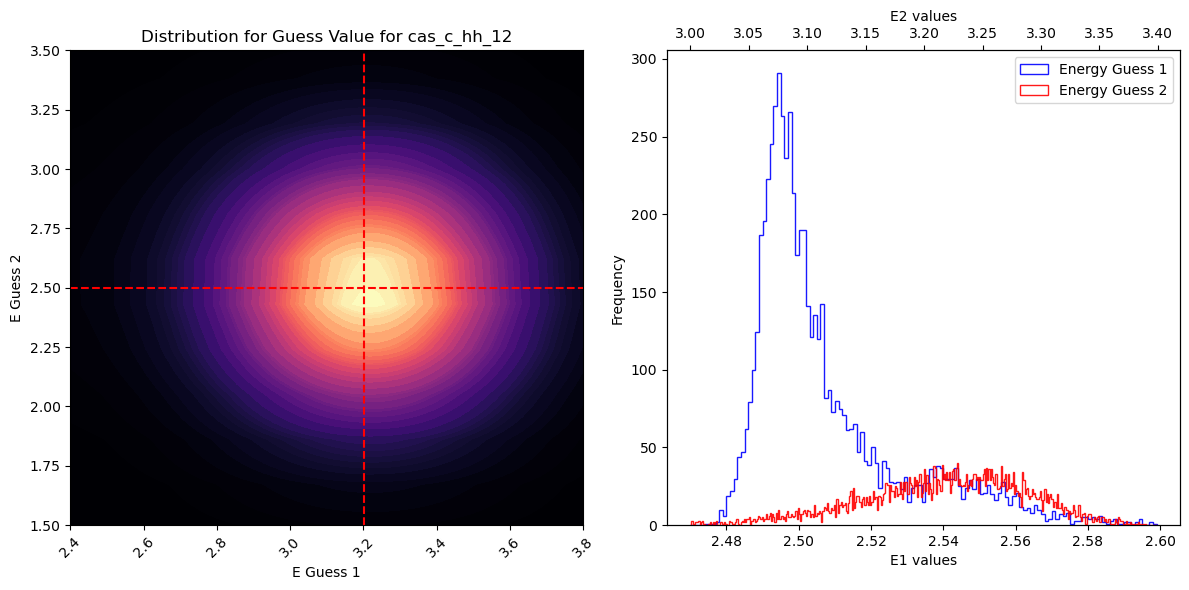

In [80]:
e_np = np.array(e)

m1 = np.median(e_np[:, 0])
m2 = np.median(e_np[:, 1])

bins_e1 = np.arange(2.47, 2.6, 0.001)
bins_e0 = np.arange(3, 3.4, 0.001)

fig, (ax_kde, ax_hist) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 6),)


sns.kdeplot(
    x=e_np[:, 0],
    y=e_np[:, 1],
    fill=True,
    cmap="magma",
    thresh=0,
    levels=40,
    ax=ax_kde
)

ax_kde.axhline(y=m2, color="red", linestyle="--")
ax_kde.axvline(x=m1, color="red", linestyle="--")

ax_kde.set_xlabel("E Guess 1")
ax_kde.set_ylabel("E Guess 2")
ax_kde.set_ylim(1.5, 3.5)
ax_kde.set_xlim(2.5, 3.8)
ax_kde.set_title(f"Distribution for Guess Value for {signal}")


xticks = list(ax_kde.get_xticks())
yticks = list(ax_kde.get_yticks())
ax_kde.set_xticks(xticks)
ax_kde.set_yticks(yticks)

for label in ax_kde.get_xticklabels():
    label.set_rotation(45)


ax1 = ax_hist

ax1.hist(
    e_np[:, 1],
    bins=bins_e1,
    alpha=0.9,
    color="blue",
    histtype="step",
    label="Energy Guess 1"
)
ax1.set_xlabel("E1 values")
ax1.set_ylabel("Frequency")

ax2 = ax1.twiny()
ax2.hist(
    e_np[:, 0],
    bins=bins_e0,
    alpha=0.9,
    color="red",
    histtype="step",
    label="Energy Guess 2"
)
ax2.set_xlabel("E2 values")
ax2.xaxis.set_ticks_position("top")
ax2.xaxis.set_label_position("top")


handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

fig.tight_layout()
plt.savefig("../assets/LMA_NG_2.png")
plt.show()


## lambcs_bc_32

In [91]:
signal = signal_list[3]
DATA_PATH = "../../../CorrelatorStudy/Bdata/ext2/"
f = open(f"{DATA_PATH}/{signal}", "r")
data = f.readlines()
f.close()

y_raw = np.array(list(map(lambda x: abs(float(x.split("\t")[-1].split("\n")[0])), data)), dtype=float)
x_raw = np.array(list(map(lambda x: float(x.split("\t")[0].split("\n")[0]), data)), dtype=float)


idx = (x_raw>=0)

x = x_raw[idx]
y = y_raw[idx]

device = "cuda:0"
BATCH_SIZE = 512
noise_dim = 64
model = Guess(feature_size=noise_dim,
              mul=4,
              nparam=4)

model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(),lr = 1e-3)


x_tensor = torch.tensor(x,device=device,dtype=torch.float64)
y_tensor = torch.tensor(y,device=device,dtype=torch.float64)

model = train_guess_network(model=model,
                            x_tensor=x_tensor,
                            y_tensor=y_tensor,
                            NEpochs=50_000,
                            optimizer=optimizer,
                            BATCH_SIZE=BATCH_SIZE,
                            noise_dim=noise_dim,
                            device=device,
                            verbose=True)

Training:   0%|          | 0/50000 [00:00<?, ?it/s]

In [92]:
with torch.no_grad():
    noise = torch.randn(6400,noise_dim,device=device)
    e,c = model(noise)
    e = e.to("cpu")

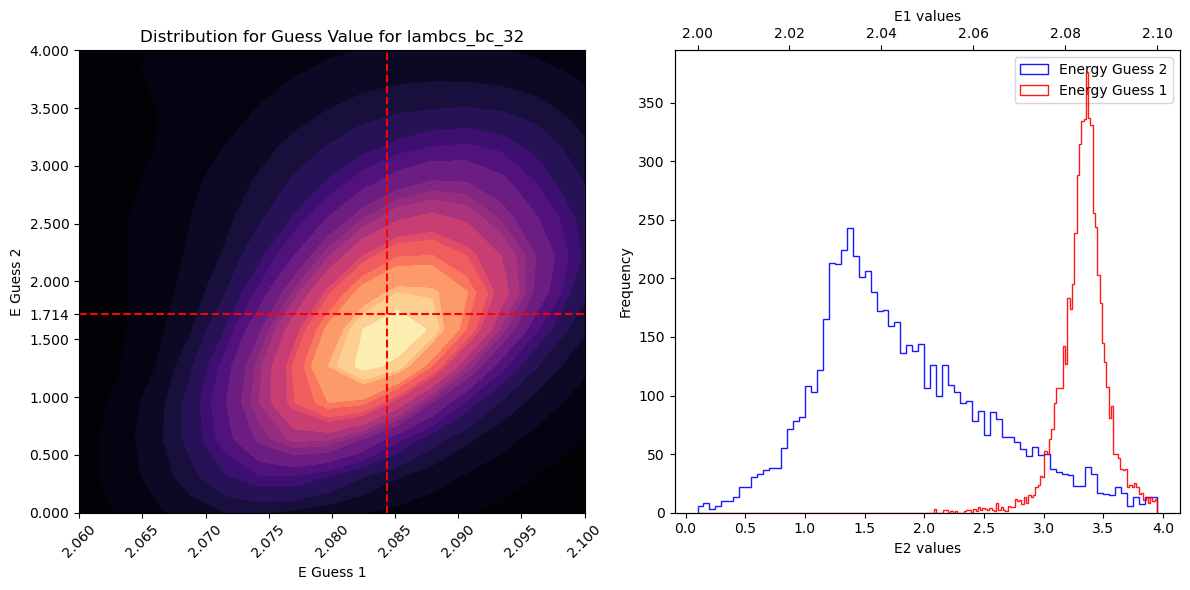

In [122]:
e_np = np.array(e)

m1 = np.median(e_np[:, 0])
m2 = np.median(e_np[:, 1])

bins_e1 = np.arange(0.1, 4, 0.05)
bins_e0 = np.arange(2, 2.1, 0.0005)

fig, (ax_kde, ax_hist) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 6),)


sns.kdeplot(
    x=e_np[:, 0],
    y=e_np[:, 1],
    fill=True,
    cmap="magma",
    thresh=0,
    levels=20,
    ax=ax_kde
)

ax_kde.axhline(y=m2, color="red", linestyle="--")
ax_kde.axvline(x=m1, color="red", linestyle="--")

ax_kde.set_xlabel("E Guess 1")
ax_kde.set_ylabel("E Guess 2")
ax_kde.set_ylim(0, 4)
ax_kde.set_xlim(2.06, 2.1)
ax_kde.set_title(f"Distribution for Guess Value for {signal}")


xticks = list(ax_kde.get_xticks())
yticks = list(ax_kde.get_yticks()) + [m2]
ax_kde.set_xticks(xticks)
ax_kde.set_yticks(yticks)

for label in ax_kde.get_xticklabels():
    label.set_rotation(45)


ax1 = ax_hist

ax1.hist(
    e_np[:, 1],
    bins=bins_e1,
    alpha=0.9,
    color="blue",
    histtype="step",
    label="Energy Guess 2"
)
ax1.set_xlabel("E2 values")
ax1.set_ylabel("Frequency")

ax2 = ax1.twiny()
ax2.hist(
    e_np[:, 0],
    bins=bins_e0,
    alpha=0.9,
    color="red",
    histtype="step",
    label="Energy Guess 1"
)
ax2.set_xlabel("E1 values")
ax2.xaxis.set_ticks_position("top")
ax2.xaxis.set_label_position("top")


handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

fig.tight_layout()
plt.savefig("../assets/LMA_NG_3.png")
plt.show()
